# 10. 시간별/가중치별 테스트

## 1. import

In [29]:
%matplotlib inline
import sys, datetime, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import networkx as nx

In [30]:
# core.py 불러오기 (경로 확인)
sys.path.append("streamlit_app")  # <- core.py가 있는 폴더
from core import (
    ensure_kst,
    load_graph_and_buildings, compute_shades_for_time,
    summarize_path, nearest_node_xy, latlng_to_xy,
    apply_edge_costs
)

In [31]:
# 고정 출발/도착 (정문 -> 북문)
START = (35.885355, 128.614666)  # 정문
END   = (35.891851, 128.609826)  # 북문

# 10월 1일 기준 (연도는 현재 연도 사용)
YEAR = datetime.date.today().year
OCT1 = datetime.date(YEAR, 10, 1)

# 외부(교외) 가로수 포함 여부 (campus 가로수는 core가 항상 포함함)
USE_TREES = False

# "메인" 가중치(지도에 굵게 그릴 경로)
W_DIST_MAIN = 8.0
W_SHADE_MAIN = 10.0 - W_DIST_MAIN

# 시간대 설정
TIME_SET = [("10 AM", 10), ("1 PM", 13), ("4 PM", 16), ("7 PM", 19)]

# 그래프/빌딩 로드
G, buildings, lat0, lng0 = load_graph_and_buildings()

## 2. 유틸 함수들

In [ ]:
def nodes_to_xy(G, nodes):
    xs = [G.nodes[n]['x'] for n in nodes]
    ys = [G.nodes[n]['y'] for n in nodes]
    return np.array(xs), np.array(ys)

def draw_shadow_rects(ax, rects, facecolor='k', alpha=0.18, edgecolor='none'):
    for r in rects:
        poly = MplPolygon(r.corners(), closed=True, facecolor=facecolor,
                          edgecolor=edgecolor, alpha=alpha)
        ax.add_patch(poly)

def draw_edges(ax, G, color='#9aa0a6', alpha=0.35, lw=1.0):
    for u, v in G.edges:
        x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
        x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
        ax.plot([x1, x2], [y1, y2], color=color, alpha=alpha, lw=lw)

def bbox_around_paths(G, *node_lists, pad=60):
    xs, ys = [], []
    for nodes in node_lists:
        for n in nodes:
            xs.append(G.nodes[n]['x']); ys.append(G.nodes[n]['y'])
    if not xs:
        return None
    return min(xs)-pad, max(xs)+pad, min(ys)-pad, max(ys)+pad

def shortest_path_with_weights(G, src, dst, w_dist, w_shade):
    apply_edge_costs(G, w_dist, w_shade)
    nodes = nx.shortest_path(G, source=src, target=dst, weight="cost")
    info = summarize_path(G, nodes)
    return nodes, info

def pct_increase(a, b):
    if b <= 1e-9:
        return 0.0 if abs(a-b) < 1e-9 else float("inf")
    return (a - b) / b * 100.0


## 3. 정문/북문을 그래프 노드로 고정

In [ ]:
sx, sy = latlng_to_xy(START[0], START[1], lat0, lng0)
dx, dy = latlng_to_xy(END[0], END[1], lat0, lng0)
SRC = nearest_node_xy(G, sx, sy)
DST = nearest_node_xy(G, dx, dy)
SRC, DST


(14, 212)

## 4. 계산 실행 (업데이트: 절대 거리/그늘 저장)

In [ ]:
results = []  # 각 시간대 결과 저장

for label, hour in TIME_SET:
    dt_local = ensure_kst(datetime.datetime(OCT1.year, 10, 1, hour, 0, 0))
    dt_iso = dt_local.replace(tzinfo=None).isoformat()

    # (1) 시간대별 그림자 계산
    rects_bld, rects_campus, rects_tree, shaded_lookup = compute_shades_for_time(
        dt_iso, use_trees=USE_TREES
    )

    # (2) 그래프에 그늘 길이 반영
    for u, v, d in G.edges(data=True):
        d["shaded_len_m"] = float(shaded_lookup.get((u, v), 0.0))

    # (3) 기준 경로 / 가중 경로
    path0_nodes, info0 = shortest_path_with_weights(G, SRC, DST, 10.0, 0.0)
    pathW_nodes, infoW = shortest_path_with_weights(G, SRC, DST, W_DIST_MAIN, W_SHADE_MAIN)

    # (4) Δ 지표 (시간대별 최단 대비)
    d_len = ((infoW["total_len_m"] - info0["total_len_m"]) / max(info0["total_len_m"], 1e-9)) * 100.0
    if info0["total_shade_m"] > 1e-9:
        d_shade_val = ((infoW["total_shade_m"] - info0["total_shade_m"]) / info0["total_shade_m"]) * 100.0
        shade_label = f"{d_shade_val:+.1f}%"
    else:
        pp = (infoW["shade_ratio"] - info0["shade_ratio"]) * 100.0
        shade_label = f"{pp:+.1f} pp"

    # (5) trade-off 곡선용 스윕 (10→6)
    wd_list, len_list, shade_pct_list = [], [], []
    for wd in np.arange(10.0, 5.9, -0.5):
        ws = 10.0 - wd
        nodes_s, info_s = shortest_path_with_weights(G, SRC, DST, wd, ws)
        wd_list.append(wd)
        len_list.append(info_s["total_len_m"])                 # ★ 절대 거리 (m)
        shade_pct_list.append(info_s["shade_ratio"] * 100.0)   # ★ Shade %

    # ★ x축 정규화용 min/max 저장
    len_min = float(np.min(len_list))
    len_max = float(np.max(len_list))

    results.append(dict(
        label=label, hour=hour,
        rects_bld=rects_bld, rects_campus=rects_campus, rects_tree=rects_tree,
        path0=path0_nodes, pathW=pathW_nodes,
        info0=info0, infoW=infoW, d_len=d_len, shade_label=shade_label,
        curve_weights=np.array(wd_list),
        curve_len_m=np.array(len_list),
        curve_shade_pct=np.array(shade_pct_list),
        len_min=len_min, len_max=len_max
    ))

len(results), [r["label"] for r in results]


(4, ['10 AM', '1 PM', '4 PM', '7 PM'])

## 4. 4개 지도 그리기 (1x4) + 수치 요약 출력

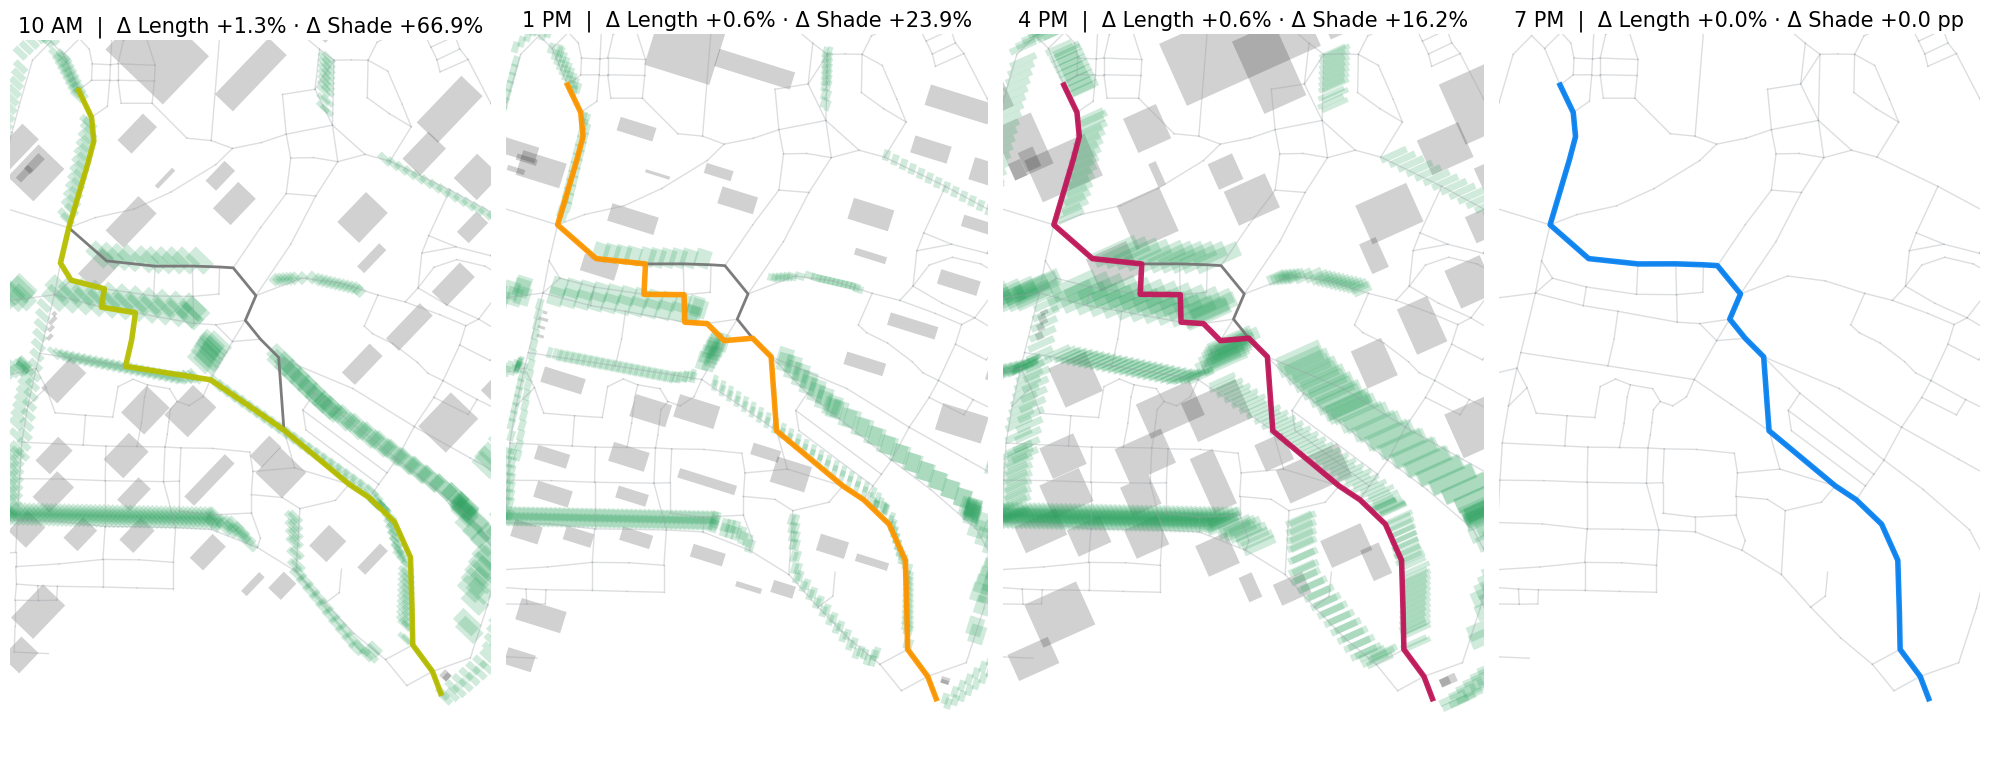

시간대,Weighted 거리(m),Weighted 그림자(m),Weighted 그림자(%),Shortest 거리(m),Shortest 그림자(m),Shortest 그림자(%)
10 AM,1003.5,338.7,33.7,990.7,202.9,20.5
1 PM,996.6,496.0,49.8,990.7,400.3,40.4
4 PM,996.6,278.4,27.9,990.7,239.5,24.2
7 PM,990.7,0.0,0.0,990.7,0.0,0.0


In [ ]:
palette = {
    "10 AM": "#b7bf00",
    "1 PM" : "#ff9800",
    "4 PM" : "#c2185b",
    "7 PM" : "#0b84f3",
}

fig, axes = plt.subplots(1, 4, figsize=(20, 10))
axes = axes.ravel()

for ax, res in zip(axes, results):
    # 배경 간선
    draw_edges(ax, G, alpha=0.35, lw=1.0)

    # 그림자(건물/교내/교외)
    draw_shadow_rects(ax, res["rects_bld"],  facecolor="black", alpha=0.18)
    draw_shadow_rects(ax, res["rects_campus"], facecolor="#2ca25f", alpha=0.22)
    draw_shadow_rects(ax, res["rects_tree"], facecolor="#2ca29c", alpha=0.22)

    # 경로
    x0, y0 = nodes_to_xy(G, res["path0"])
    xw, yw = nodes_to_xy(G, res["pathW"])
    ax.plot(x0, y0, color="#777777", lw=2.0, alpha=0.95, label="Shortest")
    ax.plot(xw, yw, color=palette[res["label"]], lw=4.0, alpha=0.95, label="Weighted")

    # 타이틀 (Δ Length, Δ Shade)
    ax.set_title(f"{res['label']}  |  Δ Length {res['d_len']:+.1f}% · Δ Shade {res['shade_label']}", fontsize=15)

    # 경로 주변 줌
    xmin, xmax, ymin, ymax = bbox_around_paths(G, res["path0"], res["pathW"])
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

plt.tight_layout()
plt.show()

# ---- (추가 부분) 4개 시간대별 경로 수치 요약 출력 ----

import pandas as pd

summary_rows = []
for res in results:
    info0 = res["info0"]  # 최단 거리 기준
    infoW = res["infoW"]  # 가중치 경로

    summary_rows.append({
        "시간대": res["label"],
        "Weighted 거리(m)": f"{infoW['total_len_m']:.1f}",
        "Weighted 그림자(m)": f"{infoW['total_shade_m']:.1f}",
        "Weighted 그림자(%)": f"{infoW['shade_ratio']*100:.1f}",
        "Shortest 거리(m)": f"{info0['total_len_m']:.1f}",
        "Shortest 그림자(m)": f"{info0['total_shade_m']:.1f}",
        "Shortest 그림자(%)": f"{info0['shade_ratio']*100:.1f}",
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary.style.set_caption("시간대별 경로 요약 (Weighted vs Shortest)")
                        .set_table_styles([{
                            "selector": "caption",
                            "props": [("caption-side", "top"), ("font-size", "15px"), ("font-weight", "bold")]
                        }])
                        .hide(axis='index'))


## 5. 모든 시간대를 한 그래프에 매끄럽게 표시 (중복 제거 포함)

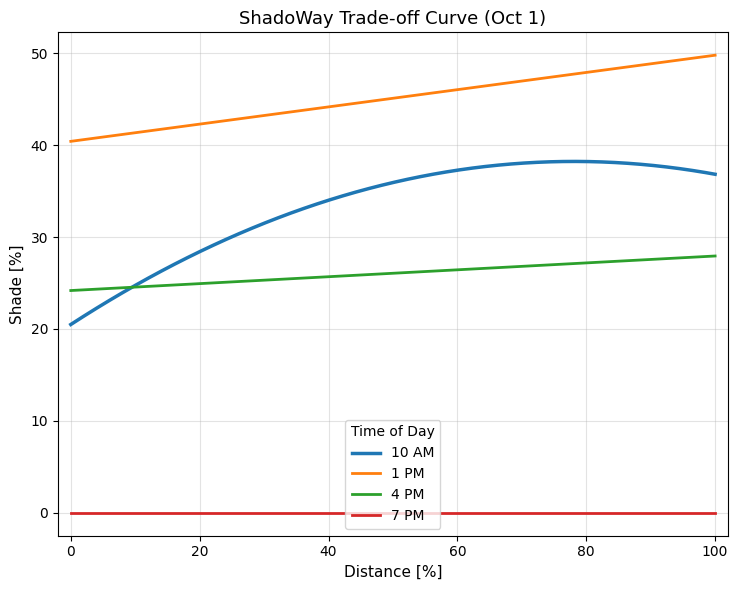

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

fig, ax = plt.subplots(figsize=(7.5, 6.0))

for res in results:
    L = res["curve_len_m"]
    S = res["curve_shade_pct"]
    Lmin, Lmax = res["len_min"], res["len_max"]

    # 정규화: 최단 거리→0%, 최장 거리→100%
    if Lmax - Lmin < 1e-9:
        x_norm = np.zeros_like(L)
    else:
        x_norm = (L - Lmin) / (Lmax - Lmin) * 100.0

    # ---- 중복 제거 ----
    uniq_x, uniq_y = [], []
    for xval in np.unique(x_norm):
        idx = np.where(np.isclose(x_norm, xval))[0]
        uniq_x.append(xval)
        uniq_y.append(np.mean(S[idx]))
    uniq_x, uniq_y = np.array(uniq_x), np.array(uniq_y)

    # ---- 곡선 보간/그리기 ----
    if len(uniq_x) >= 3 and np.ptp(uniq_x) > 1e-6:
        xs = np.linspace(uniq_x.min(), uniq_x.max(), 200)
        spline = make_interp_spline(uniq_x, uniq_y, k=min(3, len(uniq_x)-1))
        ys = spline(xs)
        ax.plot(xs, ys, lw=2.5, label=res["label"])
    else:
        # 점이 적으면 그냥 직선으로
        ax.plot([0, 100], [uniq_y[0], uniq_y[-1]], lw=2.0, label=res["label"])

# 라벨·보조선 꾸미기
ax.set_title("ShadoWay Trade-off Curve (Oct 1)", fontsize=13)
ax.set_xlabel("Distance [%]", fontsize=11)
ax.set_ylabel("Shade [%]", fontsize=11)
ax.grid(True, alpha=0.35)
ax.set_xlim(-2, 102)
ax.legend(title="Time of Day")
plt.tight_layout()
plt.show()
# fig.savefig("oct1_tradeoff_alltimes.png", dpi=200, bbox_inches="tight")


## 6. 가중치별(10, 8, 6) 실제 경로 시각화 (1×3) + 수치 요약표

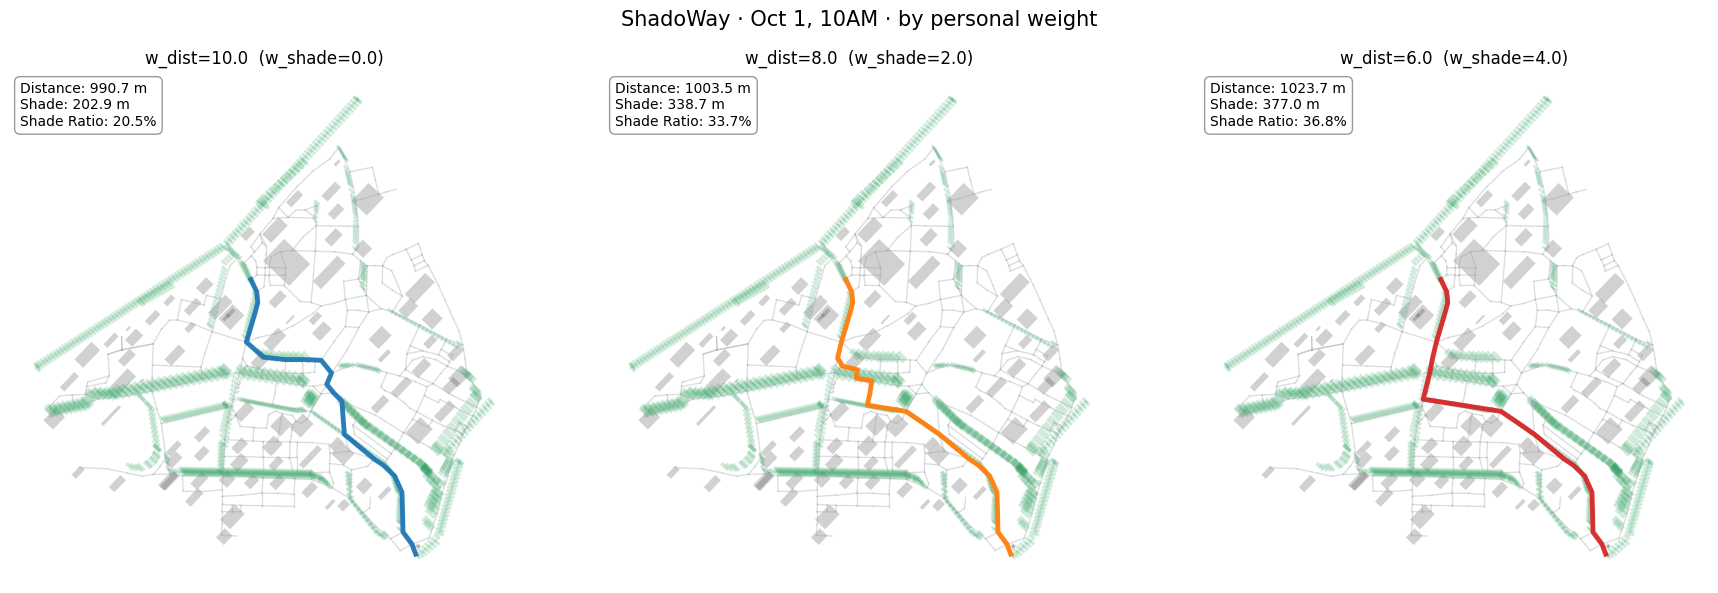

w_dist,w_shade,Distance (m),Shade (m),Shade (%)
10.0,0.0,990.7,202.9,20.5
8.0,2.0,1003.5,338.7,33.7
6.0,4.0,1023.7,377.0,36.8


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Polygon as MplPolygon

# 확인할 거리 가중치
W_LIST = [10.0, 8.0, 6.0]
palette = ["#1f77b4", "#ff7f0e", "#d62728"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.ravel()

summary_rows = []

for ax, (w_dist, color) in zip(axes, zip(W_LIST, palette)):
    w_shade = 10.0 - w_dist

    # 10월 1일 10시 기준 (원하면 변경 가능)
    dt_iso = ensure_kst(datetime.datetime(OCT1.year, 10, 1, 10, 0, 0)).replace(tzinfo=None).isoformat()
    rects_bld, rects_campus, rects_tree, shaded_lookup = compute_shades_for_time(
        dt_iso, use_trees=USE_TREES
    )

    # 간선별 그늘 반영
    for u, v, d in G.edges(data=True):
        d["shaded_len_m"] = float(shaded_lookup.get((u, v), 0.0))

    # 경로 계산
    nodes, info = shortest_path_with_weights(G, SRC, DST, w_dist, w_shade)
    xs = [G.nodes[n]['x'] for n in nodes]
    ys = [G.nodes[n]['y'] for n in nodes]

    # 지도 그리기
    draw_edges(ax, G, alpha=0.35, lw=1.0)
    draw_shadow_rects(ax, rects_bld, facecolor="black", alpha=0.18)
    draw_shadow_rects(ax, rects_campus, facecolor="#2ca25f", alpha=0.22)
    draw_shadow_rects(ax, rects_tree, facecolor="#2ca29c", alpha=0.22)
    ax.plot(xs, ys, color=color, lw=3.5, alpha=0.95, label=f"w_dist={w_dist:.1f}")

    # 정보 텍스트
    info_text = (
        f"Distance: {info['total_len_m']:.1f} m\n"
        f"Shade: {info['total_shade_m']:.1f} m\n"
        f"Shade Ratio: {info['shade_ratio']*100:.1f}%"
    )
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
            fontsize=10, va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8, boxstyle='round,pad=0.4'))

    ax.set_title(f"w_dist={w_dist:.1f}  (w_shade={w_shade:.1f})", fontsize=12)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    # 표용 데이터 저장
    summary_rows.append({
        "w_dist": f"{w_dist:.1f}",
        "w_shade": f"{w_shade:.1f}",
        "Distance (m)": f"{info['total_len_m']:.1f}",
        "Shade (m)": f"{info['total_shade_m']:.1f}",
        "Shade (%)": f"{info['shade_ratio']*100:.1f}"
    })

plt.suptitle("ShadoWay · Oct 1, 10AM · by personal weight", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ---- (추가) 수치 요약표 출력 ----
df_summary = pd.DataFrame(summary_rows)
display(df_summary.style.set_caption("가중치별 경로 요약 (10, 8, 6)")
                        .set_table_styles([{
                            "selector": "caption",
                            "props": [("caption-side", "top"),
                                      ("font-size", "15px"),
                                      ("font-weight", "bold")]
                        }])
                        .hide(axis='index'))


## 7. 모든 가중치 경로를 한 지도에 겹쳐서 표시

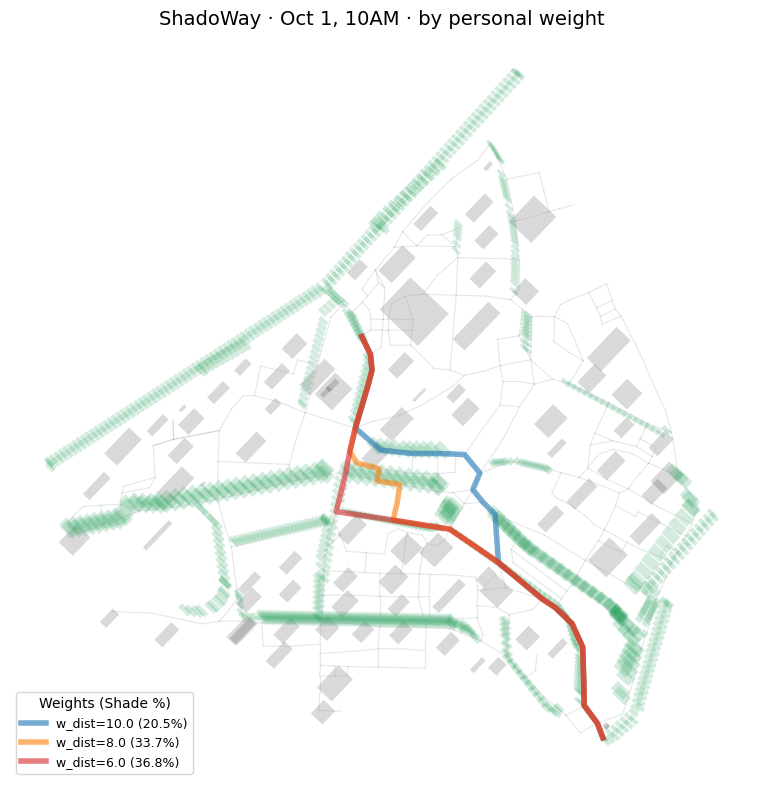

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

W_LIST = [10.0, 8, 6.0]
palette = ["#1f77b4", "#ff7f0e",  "#d62728"]

# 시간대 설정 (예: 10AM)
dt_iso = ensure_kst(datetime.datetime(OCT1.year, 10, 1, 10, 0, 0)).replace(tzinfo=None).isoformat()
rects_bld, rects_campus, rects_tree, shaded_lookup = compute_shades_for_time(
    dt_iso, use_trees=USE_TREES
)

# 간선별 그늘 반영
for u, v, d in G.edges(data=True):
    d["shaded_len_m"] = float(shaded_lookup.get((u, v), 0.0))

fig, ax = plt.subplots(figsize=(8, 8))

# 배경 (도로망 + 그림자)
draw_edges(ax, G, alpha=0.25, lw=0.8)
draw_shadow_rects(ax, rects_bld, facecolor="black", alpha=0.15)
draw_shadow_rects(ax, rects_campus, facecolor="#2ca25f", alpha=0.20)
draw_shadow_rects(ax, rects_tree, facecolor="#2ca29c", alpha=0.20)

# 경로 그리기 (투명도 낮게)
for w_dist, color in zip(W_LIST, palette):
    w_shade = 10.0 - w_dist
    nodes, info = shortest_path_with_weights(G, SRC, DST, w_dist, w_shade)
    xs = [G.nodes[n]['x'] for n in nodes]
    ys = [G.nodes[n]['y'] for n in nodes]

    ax.plot(xs, ys, color=color, lw=4, alpha=0.6, label=f"w_dist={w_dist:.1f} ({info['shade_ratio']*100:.1f}%)")

# 제목 / 범례
ax.set_title("ShadoWay · Oct 1, 10AM · by personal weight", fontsize=14)
ax.legend(title="Weights (Shade %)", loc="lower left", fontsize=9)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")

plt.tight_layout()
plt.show()
# fig.savefig("oct1_10AM_allweights_transparent.png", dpi=200, bbox_inches="tight")
